In [1]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainwidemap.bwm_loading import merge_probes
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox.singlecell import bin_spikes2D
import numpy as np
from iblatlas.atlas import BrainRegions
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import itertools
import pickle as pkl
from tqdm import tqdm
from pathlib import Path
import warnings
from sklearn.ensemble import RandomForestClassifier
from ibl_info.prepare_data_pid import (
    cleaned_regions_flags,
    get_new_cinc_intervals,
    prepare_ephys_data,
)
from ibl_info.utils import (
    alternate_discretize,
    compute_mutual_information,
    compute_pid,
    compute_trivariate_mi,
    FIRING_RATE,
    discretize,
    discretize_keeping_zeros,
    equipopulated_binning,
)
import os
import concurrent.futures
import functools
import random
from ibl_info.utils import check_config

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
one = ONE()
df_parq = pd.read_parquet("../data/external/stimside_stage2.pqt")
unit_df = bwm_units(one)

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01


In [4]:
config = check_config()

In [5]:
important_regions = config["stim_prior_regions"]

In [6]:
df_filter = df_parq[df_parq["region"].isin(important_regions)]

In [7]:
significant_dfs = df_filter[df_filter["p-value"] < 0.05]

In [8]:
len(significant_dfs["eid"].unique())

179

In [9]:
# rearrange both the decoders and the single cell results

In [10]:
# try the new filter eid function
from ibl_info.selective_decomposition import filter_eids

In [ ]:
one = ONE()
unit_df = bwm_units(one)

og_eids_change = np.zeros((len(important_regions), 2))
for idx, region in enumerate(important_regions):
    eids = filter_eids(unit_df, region)
    eids_significant = filter_eids(unit_df, region, significant_filter=True)
    og_eids_change[idx, 0] = len(eids)
    og_eids_change[idx, 1] = len(eids_significant)

Text(0.5, 1.0, 'EIDs')

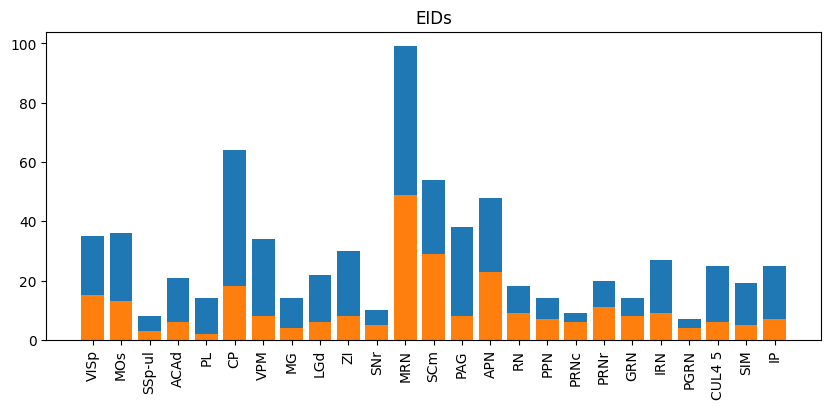

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(np.arange(len(important_regions)), og_eids_change[:, 0], label="og-filter")
ax.bar(np.arange(len(important_regions)), og_eids_change[:, 1], label="sig-filter")
ax.set_xticks(np.arange(len(important_regions)), important_regions, rotation=90)
ax.set_title("EIDs")

### Single example

In [25]:
subject_id = "CSH_ZAD_022"
eid = "a82800ce-f4e3-4464-9b80-4c3d6fade333"
session_id = eid

In [26]:
# great decoding in LGd

In [27]:
# now to download data, and other stuff

In [28]:
from ibl_info.utils import download_data


one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")
# try:
#     pids, probes = one.eid2pid(eid)  # type: ignore
#     for pid in pids:
#         download_data(one, pid)
# except Exception as e:
#     print(e)

In [29]:
# look at decoder accuracy from LOOCV loop

In [30]:
# load data from LGd

In [ ]:
session_id = eid
pids, probes = one.eid2pid(session_id)
if isinstance(probes, list) and len(probes) > 1:
    to_merge = [load_good_units(one, pid=pid, qc=1) for pid in pids]
    spikes, clusters = merge_probes(
        [spikes for spikes, _ in to_merge], [clusters for _, clusters in to_merge]
    )
else:
    spikes, clusters = load_good_units(one, pid=pids[0], qc=1)

trials, mask = load_trials_and_mask(one, session_id, exclude_nochoice=True, exclude_unbiased=True)
trials = trials[mask]

In [33]:
intervals, target_variable, congruent_flags, incongruent_flags = get_new_cinc_intervals(
    trials, "stim"
)

In [34]:
binned_spikes, actual_regions, n_units, cluster_uuids_list = prepare_ephys_data(
    spikes, clusters, intervals, ["LGd"], minimum_units=5
)  # this returns all neurons from a single region that pass qc
# however, it is in trials x neurons

spike_data = binned_spikes[0].T

congruent_target = target_variable[congruent_flags]
incongruent_target = target_variable[incongruent_flags]

congruent_spikes = spike_data[:, congruent_flags]
incongruent_spikes = spike_data[:, incongruent_flags]

Region found LGd, 67


In [35]:
from ibl_info.decoder_pid import linear_nonlinear_delta
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, Lasso
from sklearn.model_selection import LeaveOneOut
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, balanced_accuracy_score, r2_score
from ibl_info.decoder_pid import linear_nonlinear_delta

# do this manually

In [36]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, r2_score

In [37]:
information_pickle = {}
trial_count = np.zeros((3))

trial_count[0] = intervals.shape[0]
trial_count[1] = np.sum(congruent_flags)
trial_count[2] = np.sum(incongruent_flags)
information_pickle["neurons"] = spike_data.shape[0]
information_pickle["trials"] = trial_count

In [38]:
import warnings
from ibl_info.decoder_pid import subsampled

warnings.filterwarnings("ignore")

In [39]:
linear_nonlinear_delta(trial_types=target_variable, neural_activity=spike_data.T)

(0.777172619047619, 0.8126190476190476, 0.035446428571428545)

In [41]:
linear_nonlinear_delta(trial_types=incongruent_target, neural_activity=incongruent_spikes.T)

(0.8149920255183413, 0.8201754385964912, 0.0051834130781499566)

In [47]:
with open(
    "../data/generated/decoded/all/selective_decomposition_GRN_stim_decoder_alldata_goodsessions.pkl",
    "rb",
) as f:
    all_data_accuracy_svmnon = pkl.load(f)

In [48]:
all_data_accuracy_svmnon

{'25d1920e-a2af-4b6c-9f2e-fc6c65576544': {'neurons': 68,
  'trials': array([191., 149.,  42.]),
  'all_data_delta': (0.5317625317625317,
   0.5834488334488335,
   0.05168630168630173)},
 '32d27583-56aa-4510-bc03-669036edad20': {'neurons': 34,
  'trials': array([476., 391.,  85.]),
  'all_data_delta': (0.6153314297002676,
   0.6144065513711546,
   -0.0009248783291129214)},
 '56b57c38-2699-4091-90a8-aba35103155e': {'neurons': 72,
  'trials': array([355., 280.,  75.]),
  'all_data_delta': (0.6427027714213069,
   0.6838768115942029,
   0.04117404017289594)},
 '671c7ea7-6726-4fbe-adeb-f89c2c8e489b': {'neurons': 68,
  'trials': array([484., 393.,  91.]),
  'all_data_delta': (0.6565008025682183,
   0.6685997342032137,
   0.012098931634995425)},
 '746d1902-fa59-4cab-b0aa-013be36060d5': {'neurons': 34,
  'trials': array([412., 342.,  70.]),
  'all_data_delta': (0.6789150943396227,
   0.6662735849056604,
   -0.012641509433962361)},
 'aec5d3cc-4bb2-4349-80a9-0395b76f04e2': {'neurons': 45,
  'tria

In [43]:
A = subsampled(congruent_spikes, congruent_target, incongruent_target, decoder_pid=False)

array([0.68859649, 0.73389155, 0.04529506])

array([0.7300638 , 0.80717703, 0.07711324])

In [36]:
information_pickle["congruent_delta_mlp"]

array([[ 0.61881978,  0.65629984,  0.03748006],
       [ 0.74322169,  0.69976077, -0.04346093],
       [ 0.78867624,  0.87161085,  0.08293461],
       [ 0.76754386,  0.78269537,  0.01515152],
       [ 0.78269537,  0.70374801, -0.07894737]])

In [ ]:
# all_data_accuracy_svmnon = linear_nonlinear_delta(
#     trial_types=target_variable, neural_activity=spike_data.T, nonlinear_model="svm_rbf"
# )

# all_data_accuracy_mlpnon = linear_nonlinear_delta(
#     trial_types=target_variable, neural_activity=spike_data.T, nonlinear_model="mlp"
# )

# all_data_accuracy_rfnon = linear_nonlinear_delta(
#     trial_types=target_variable, neural_activity=spike_data.T, nonlinear_model="random_forest"
# )

In [ ]:
from ibl_info.decoder_pid import compute_decoder_pid


incongruent_pid = compute_decoder_pid(incongruent_target, incongruent_spikes.T)

In [42]:
np.mean(incongruent_pid, axis=0)

array([ 0.02095428, -0.01813931,  0.22008673,  0.14493528,  0.77887324,
        0.75492958])

In [ ]:
congruent_pid = compute_decoder_pid(congruent_target, congruent_spikes.T)

In [44]:
np.mean(congruent_pid, axis=0)

array([0.01862468, 0.0191934 , 0.23297842, 0.07044249, 0.76182432,
       0.75608108])

In [ ]:
from ibl_info.decoder_pid import subsampled


all_congruent_values = subsampled(congruent_spikes, congruent_target, incongruent_target)

In [95]:
np.mean(all_congruent_values, axis=0)

array([0.0301553 , 0.01488345, 0.11841278, 0.09653118])

In [45]:
np.mean(incongruent_pid, axis=0)

array([ 0.02095428, -0.01813931,  0.22008673,  0.14493528,  0.77887324,
        0.75492958])

In [ ]:
all_data = compute_decoder_pid(target_variable, spike_data.T)

In [129]:
# now what about the og single cell pid

In [99]:
from ibl_info.selective_decomposition import run_analysis_single_session


info_pickle = run_analysis_single_session(
    session_id, "stim", one, "LGd", discretize_method=1, single_cell_filter=False
)

Region found LGd, 67
Region found LGd, 67


In [102]:
info_pickle.keys()

dict_keys(['trials', 'neurons', 'average_spikes', 'all', 'congruent', 'incongruent', 'subsampled'])

In [104]:
np.mean(info_pickle["congruent"]["pid"], axis=0)

array([0.03759479, 0.0114483 , 0.00477442, 0.00196344])

In [105]:
np.mean(info_pickle["incongruent"]["pid"], axis=0)

array([0.04684434, 0.01351477, 0.0083617 , 0.00158548])

In [106]:
np.mean(info_pickle["all"]["pid"], axis=0)

array([0.04002769, 0.01190978, 0.00455859, 0.00230845])

In [107]:
# combine all this into a single plot

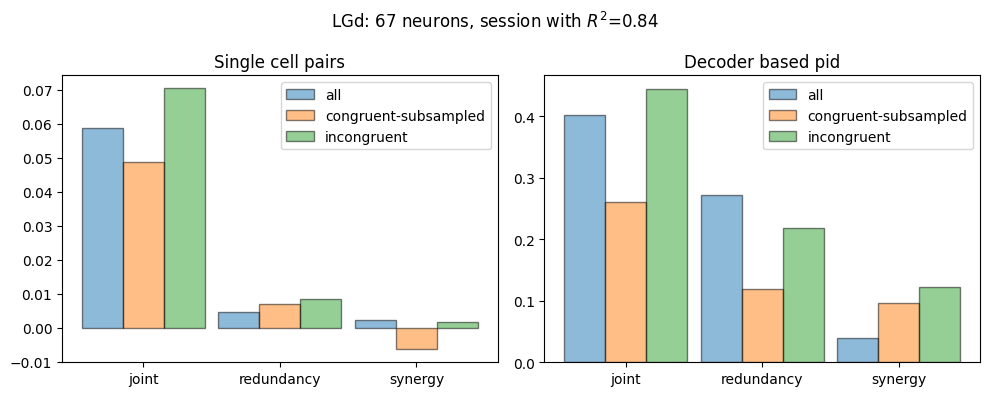

In [140]:
fig, ax = plt.subplots(figsize=(10, 4), ncols=2)

ax[0].bar(
    np.arange(3),
    [
        np.sum(np.mean(info_pickle["all"]["pid"], axis=0)),
        np.mean(info_pickle["all"]["pid"], axis=0)[2],
        np.mean(info_pickle["all"]["pid"], axis=0)[3],
    ],
    width=0.3,
    edgecolor="k",
    alpha=0.5,
    label="all",
)

ax[0].bar(
    np.arange(3) + 0.3,
    [
        np.sum(np.mean(info_pickle["subsampled"]["pid"], axis=0)),
        np.mean(info_pickle["subsampled"]["pid"], axis=0)[2],
        np.mean(info_pickle["subsampled"]["pid"], axis=0)[3],
    ],
    width=0.3,
    edgecolor="k",
    alpha=0.5,
    label="congruent-subsampled",
)
ax[0].bar(
    np.arange(3) + 0.6,
    [
        np.sum(np.mean(info_pickle["incongruent"]["pid"], axis=0)),
        np.mean(info_pickle["incongruent"]["pid"], axis=0)[2],
        np.mean(info_pickle["incongruent"]["pid"], axis=0)[3],
    ],
    width=0.3,
    edgecolor="k",
    alpha=0.5,
    label="incongruent",
)
ax[0].legend()
ax[0].set_xticks(np.arange(3) + 0.3, ["joint", "redundancy", "synergy"])
ax[0].set_title("Single cell pairs")

# ------
ax[1].bar(
    np.arange(3),
    [
        np.sum(np.mean(all_data, axis=0)),
        np.mean(all_data, axis=0)[2],
        np.mean(all_data, axis=0)[3],
    ],
    width=0.3,
    edgecolor="k",
    alpha=0.5,
    label="all",
)

ax[1].bar(
    np.arange(3) + 0.3,
    [
        np.sum(np.mean(all_congruent_values, axis=0)),
        np.mean(all_congruent_values, axis=0)[2],
        np.mean(all_congruent_values, axis=0)[3],
    ],
    width=0.3,
    edgecolor="k",
    alpha=0.5,
    label="congruent-subsampled",
)
ax[1].bar(
    np.arange(3) + 0.6,
    [
        np.sum(np.mean(incongruent_pid, axis=0)),
        np.mean(incongruent_pid, axis=0)[2],
        np.mean(incongruent_pid, axis=0)[3],
    ],
    width=0.3,
    edgecolor="k",
    alpha=0.5,
    label="incongruent",
)
ax[1].legend()
ax[1].set_xticks(np.arange(3) + 0.3, ["joint", "redundancy", "synergy"])
ax[1].set_title("Decoder based pid")
plt.suptitle("LGd: 67 neurons, session with $R^2$=0.84")
plt.tight_layout()

### Single eid, significant neurons with MI from region

In [1]:
from ibl_info.significant_mi_neurons import find_significant_neurons_sessions

In [13]:
results = find_significant_neurons_sessions(
    session_id=session_id, epoch="stim", one=one, region="LGd"
)

Region found LGd, 67


In [10]:
# with open(f"../data/processed/cellmi/single_cell_mi_{session_id}.pkl", "wb") as f:
#     pkl.dump(results, f)

with open(f"../data/processed/cellmi/single_cell_mi_{session_id}.pkl", "rb") as f:
    results_old = pkl.load(f)

In [16]:
results["uuids"][results["reject"]]

array([602, 614, 619, 626, 635, 638, 639, 658, 659, 660, 661, 665, 672,
       679, 687, 694])

In [18]:
np.asarray(results_old["uuids"])[results_old["reject"]]

array([602, 614, 619, 626, 635, 638, 639, 658, 659, 660, 661, 666, 672,
       679, 687, 694])

In [10]:
config = check_config()

In [6]:
from ibl_info.selective_decomposition import run_analysis_single_session

In [19]:
ipickle = run_analysis_single_session(
    session_id=session_id, one=one, region="LGd", discretize_method=1, epoch="stim"
)

Region found LGd, 67
Region found LGd, 67


In [13]:
with open(
    "../data/generated/test_CSH_ZAD_022_a82800ce-f4e3-4464-9b80-4c3d6fade333.pkl", "rb"
) as f:
    d = pkl.load(f)

In [16]:
np.mean(d["incongruent"]["pid"], axis=0)

array([0.0451779 , 0.06961648, 0.07735684, 0.0379307 ])

In [17]:
np.mean(d["subsampled"]["pid"], axis=0)

array([0.04145366, 0.05913144, 0.05145433, 0.02506049])

In [18]:
np.mean(d["congruent"]["pid"], axis=0)

array([0.03700783, 0.05400724, 0.05380002, 0.02807531])

In [20]:
np.mean(ipickle["incongruent"]["pid"], axis=0)

array([4.77402509e-02, 1.30425591e-02, 7.97040731e-03, 5.07999514e-05])

In [21]:
np.mean(ipickle["congruent"]["pid"], axis=0)

array([0.03776407, 0.01143134, 0.00473135, 0.00186879])

### Decoder PID results